#  Tumor Type Classification Using Logestic Regression.

### [Dataset link on kaggle](https://www.kaggle.com/datasets/erdemtaha/cancer-data)

---

## Preprocessing

Importing Libraries

In [2]:
import seaborn as sns
# ==================================================
import matplotlib.pyplot as plt
# ==================================================
#read dataset.
from pandas import read_csv
import pandas as pd
# ==================================================
# to hold the empty cell and fil it.
import numpy as np
# ==================================================
#to make data encoding (make the target column values = 0 and 1).
# TO make the range of all dataset values in range[0,1] 
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
#to train the model and apply naive bayes .
from sklearn.naive_bayes import GaussianNB
#to split dataset into xtrain-ytrain and xtest-ytest.
from sklearn.model_selection import train_test_split
#to apply logisticregregression algorithm and train the model.
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
#to make data cleaning and handle the missing values.
from sklearn.impute import SimpleImputer as si
# ----------------------------------------------------
# System Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, zero_one_loss

load cancer dataset and use `head()` function to see the first 5 rows of the dataset.

In [3]:
CancerData = read_csv("E:\programming_languages\Cancer_Data.csv")
CancerData.dropna(axis=1, inplace=True)

In [4]:
print(CancerData.head(3))

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38           122.8     1001.0   
1    842517         M        20.57         17.77           132.9     1326.0   
2  84300903         M        19.69         21.25           130.0     1203.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   

   ...  radius_worst  texture_worst  perimeter_worst  area_worst  \
0  ...         25.38          17.33            184.6      2019.0   
1  ...         24.99          23.41            158.8      1956.0   
2  ...         23.57          25.53            152.5      1709.0   

   smoothness_worst  compactness_worst  concavity_worst  concave points_worst  \
0            0.1622 

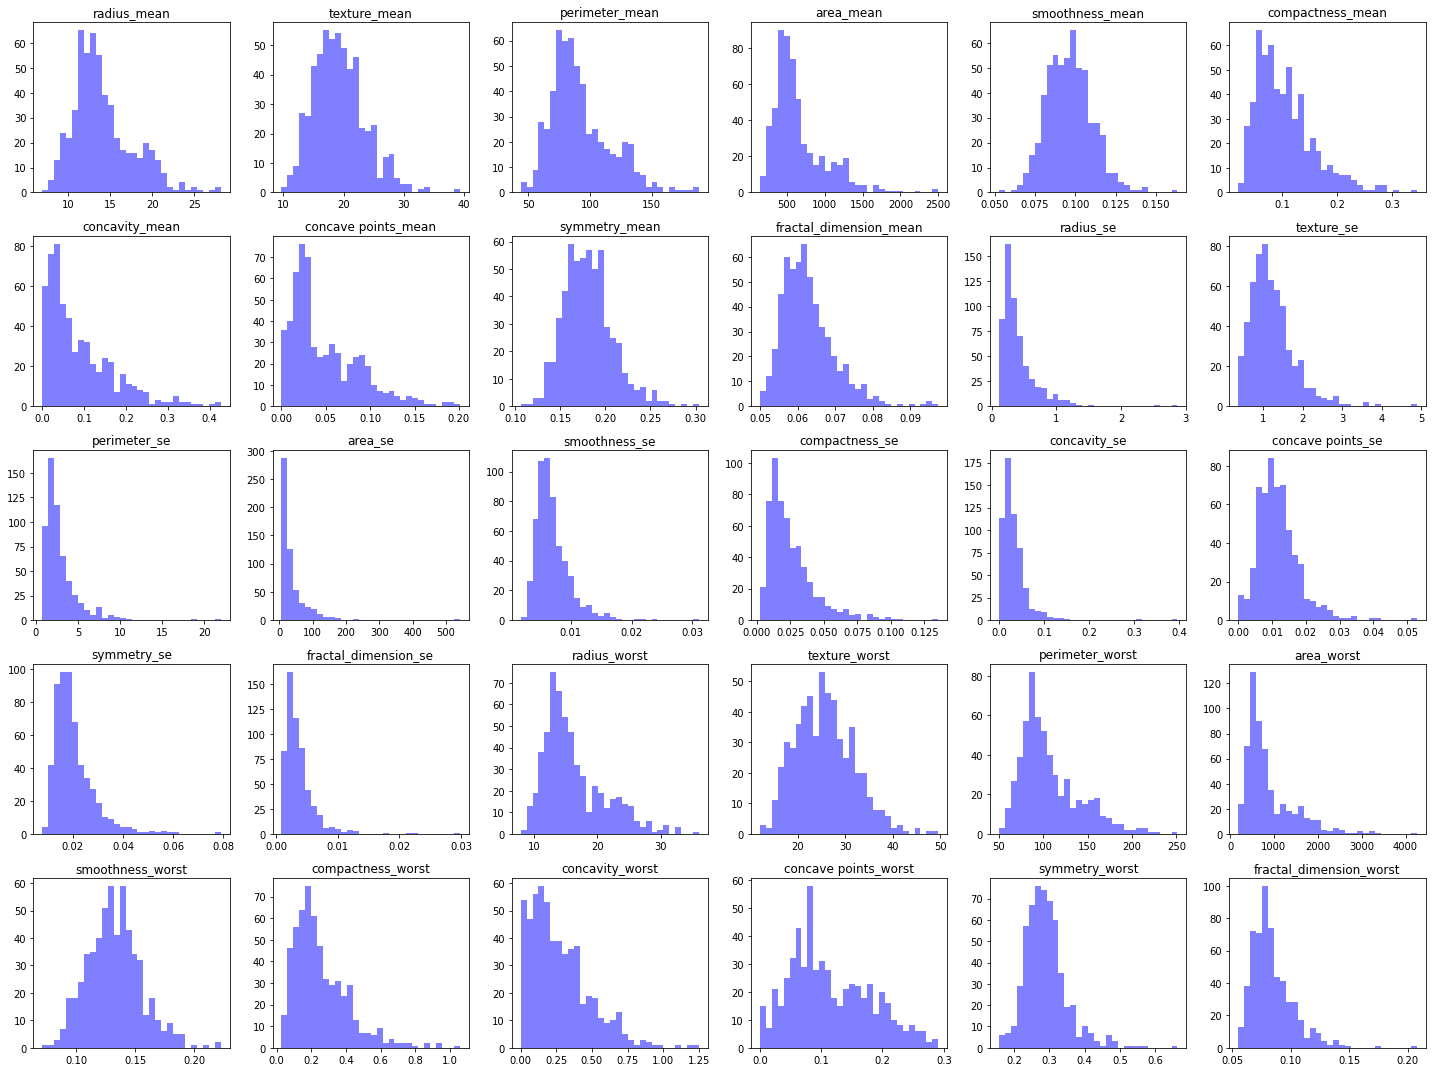

In [5]:
rows = 5
col = 6
fig, axs = plt.subplots(rows, col, figsize=(20, 15))
axs = axs.ravel()
for i in range(rows * col):
    axs[i].hist(CancerData.iloc[:, i+2], bins=30, color='b', alpha=0.5)
    axs[i].set_title(CancerData.columns[i+2])
plt.tight_layout()
plt.show()

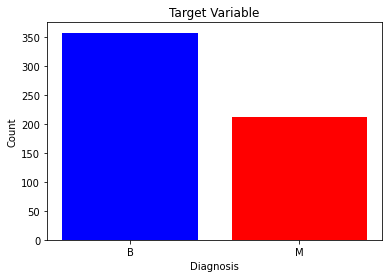

In [6]:
# Plot a bar chart of the target variable
target_counts = CancerData['diagnosis'].value_counts()
plt.bar(target_counts.index, target_counts.values, color=['blue', 'red'])
plt.title('Target Variable')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

`X` is the data of all features (all columns except the diagnosis column).

In [7]:
X = CancerData.iloc[:, 2:].values

print(X.shape)
# print(X[:5])

(569, 30)


Now we normalize the data using `MinMaxScaler()` function.
We normalize the data because we want to scale down all the features to be in the same range, so that no feature will dominate the other features.
Doing this will improve model accuracy.

`MinMaxScaler()` is a function that scales down all the features to be in the range of `0` to `1`. 

In [8]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
# print(X[:5])

`y` is the data of the diagnosis column.

In [9]:
y = CancerData.iloc[:, 1].values
print(y.shape)
# print(y[:5])

(569,)


SimpleImputer function will take the missing cells that contain "nan" value and fill them by the mean of their columns.

In [10]:
imputer = si(missing_values=np.nan,strategy='mean')
X = imputer.fit_transform(X)

Change the values of `y` to be `0` and `1` instead of `M` and `B` using `LabelEncoder()` function so that some tests can be applied on it.

In [11]:
le = LabelEncoder()
y = le.fit_transform(y)
# print(y[:5])

Splitting data using `train_test_split()` function.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

## Applying LogisticRegression Model 

In [13]:
LogisticRegressionModel = LogisticRegression(solver='sag',C=1,random_state=33,max_iter=100)

Training the model using `fit()` function.

In [14]:
LogisticRegressionModel.fit(X_train, y_train)

LogisticRegression(C=1, random_state=33, solver='sag')

### Model Accuracy & Confusion Matrix

Calculating Details

`[0, 1]` which means Malignant and Benign

Logistic regression number of iterations is the number of iterations that the solver used to converge.

In [15]:
print('LogisticRegressionModel Train Score is: ' , LogisticRegressionModel.score(X_train, y_train))
print('LogisticRegressionModel Test Score is: ' , LogisticRegressionModel.score(X_test, y_test))
print('LogisticRegressionModel Classes are: ' , LogisticRegressionModel.classes_)
print('LogisticRegressionModel No. of iteratios is: ' , LogisticRegressionModel.n_iter_)

LogisticRegressionModel Train Score is:  0.967032967032967
LogisticRegressionModel Test Score is:  0.9824561403508771
LogisticRegressionModel Classes are:  [0 1]
LogisticRegressionModel No. of iteratios is:  [30]


The output above before normalization was:
```
LogisticRegressionModel Train Score is :  0.9028871391076115
LogisticRegressionModel Test Score is :  0.9574468085106383
LogisticRegressionModel Classes are :  [0 1]
LogisticRegressionModel No. of iteratios is :  [4250]
```

Calculating Prediction

In [16]:
y_pred = LogisticRegressionModel.predict(X_test)
y_pred_prob = LogisticRegressionModel.predict_proba(X_test)
print('Predicted Value for LogisticRegressionModel is: ' , y_pred[:10])
print('Prediction Probabilities Value for LogisticRegressionModel is: \n' , y_pred_prob[:10])

Predicted Value for LogisticRegressionModel is:  [1 1 0 1 0 0 0 0 1 0]
Prediction Probabilities Value for LogisticRegressionModel is: 
 [[0.34297674 0.65702326]
 [0.00404483 0.99595517]
 [0.94342805 0.05657195]
 [0.00235078 0.99764922]
 [0.67951732 0.32048268]
 [0.92114572 0.07885428]
 [0.98831329 0.01168671]
 [0.73492134 0.26507866]
 [0.02111136 0.97888864]
 [0.98433854 0.01566146]]


Calculating Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix is: \n', cm)

Confusion Matrix is: 
 [[75  0]
 [ 2 37]]


$TP = 118$ , $TN = 63$ , $FP = 0$ , $FN = 2$

 Drawing confusion matrix

 ![Confusion Matrix](https://research.aimultiple.com/wp-content/webp-express/webp-images/uploads/2019/07/positive-negative-true-false-matrix.png.webp)

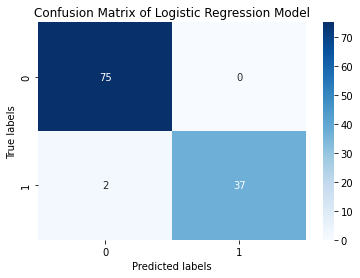

In [18]:
# Data visualization of the confusion matrix
photo = sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
photo.set_xlabel('Predicted labels')
photo.set_ylabel('True labels')
photo.set_title('Confusion Matrix of Logistic Regression Model')
plt.show()
photo.figure.savefig('logistic_regression_confusion_matrix.png')

Calculating Accuracy Score  : $\frac{TP + TN}{TP + TN + FP + FN}$ which means True values (Positive & Negative) divided by all values.

```T = True, F = False, P = Positive, N = Negative
TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative 
```

True means correct, and false means incorrect.

In [19]:
AccScore = accuracy_score(y_test, y_pred) #, normalize=False
print('Accuracy Score is: ', AccScore)

Accuracy Score is:  0.9824561403508771


Calculating Zero One Loss :

In [20]:
ZeroOneLossValue = zero_one_loss(y_test,y_pred,normalize=False) 
print('Zero One Loss Value: ', ZeroOneLossValue )

Zero One Loss Value:  2


# Applying KNN Model

Training the K-NN model on the Training set.

from class neighbor in sklearn library import KNeighborsClassifier function to train model on training data.

`KNeighborsClassifier` function take K , and work in euchleaden distence (p=2).

In [21]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 20, metric = 'minkowski', p = 2)

Training the K-NN model on the Training set.
from class neighbor in `sklearn` library import `KNeighborsClassifier` function to train model on training data.
`KNeighborsClassifier` function take K , and work in euchleaden distence (p=2).

In [22]:
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=20)

In [23]:
y_pred = classifier.predict(X_test)
y_pred_prob = classifier.predict_proba(X_test)
print('Predicted Value for KNN Model is: ' , y_pred[:10])
print('Prediction Probabilities Value for KNN Model is: \n' , y_pred_prob[:10])

Predicted Value for KNN Model is:  [1 1 0 1 0 0 0 0 1 0]
Prediction Probabilities Value for KNN Model is: 
 [[0.25 0.75]
 [0.   1.  ]
 [0.9  0.1 ]
 [0.   1.  ]
 [0.6  0.4 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.95 0.05]
 [0.   1.  ]
 [1.   0.  ]]


 Drawing confusion matrix

 ![Confusion Matrix](https://research.aimultiple.com/wp-content/webp-express/webp-images/uploads/2019/07/positive-negative-true-false-matrix.png.webp)

In [24]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75  0]
 [ 2 37]]


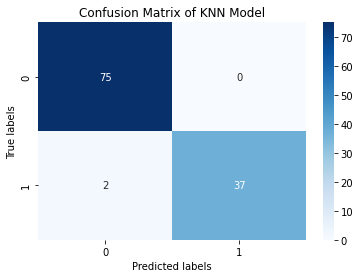

In [25]:
# Data visualization of the confusion matrix
# plt.figure(figsize=(10,10))
photo = sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
photo.set_xlabel('Predicted labels')
photo.set_ylabel('True labels')
photo.set_title('Confusion Matrix of KNN Model')
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
photo.figure.savefig('knn_confusion_matrix.png')

In [26]:
AccScore = accuracy_score(y_test, y_pred) #, normalize=False
print('Accuracy Score is: ', AccScore)

Accuracy Score is:  0.9824561403508771


In [27]:
ZeroOneLossValue = zero_one_loss(y_test,y_pred,normalize=False) 
print('Zero One Loss Value: ', ZeroOneLossValue )

Zero One Loss Value:  2


# Applying GridSearchCV Model

In [28]:

#apply hyperprameter (GridSearchCv)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 20], 'metric': ['euclidean', 'manhattan', 'minkowski'], 'p': [1, 2]}

Use GridSearchCV to find the best hyperparameters

In [29]:
grid = GridSearchCV(classifier, param_grid, refit=True, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END metric=euclidean, n_neighbors=3, p=1;, score=0.934 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3, p=1;, score=0.978 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=3, p=1;, score=0.978 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3, p=1;, score=0.956 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3, p=1;, score=0.978 total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=3, p=2;, score=0.934 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3, p=2;, score=0.978 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=3, p=2;, score=0.978 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3, p=2;, score=0.956 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3, p=2;, score=0.978 total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=5, p=1;, score=0.934 total time=   0.0s
[CV 2/5] END metric=eucli

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11, 20], 'p': [1, 2]},
             verbose=3)

In [30]:
print(grid.best_score_)
print(grid.best_params_)

0.9692307692307693
{'metric': 'euclidean', 'n_neighbors': 9, 'p': 1}


### Model Accuracy & Confusion Matrix

In [31]:
y_pred = grid.predict(X_test)
y_pred_prob = grid.predict_proba(X_test)
print('Predicted Value for  GRID SEARCH KNN Model is: ' , y_pred[:10])
print('Prediction Probabilities Value for GRID SEARCH KNN Model is: \n' , y_pred_prob[:10])

Predicted Value for  GRID SEARCH KNN Model is:  [1 1 0 1 0 0 0 0 1 0]
Prediction Probabilities Value for GRID SEARCH KNN Model is: 
 [[0.11111111 0.88888889]
 [0.         1.        ]
 [1.         0.        ]
 [0.         1.        ]
 [0.66666667 0.33333333]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.         1.        ]
 [1.         0.        ]]


In [32]:
print('GridSearchCV Train Score is: ' , grid.score(X_train, y_train))
print('GridSearchCV Test Score is: ' , grid.score(X_test, y_test))
print('GridSearchCV Classes are: ' , grid.classes_) # [0 1] means B and M

GridSearchCV Train Score is:  0.9802197802197802
GridSearchCV Test Score is:  0.9824561403508771
GridSearchCV Classes are:  [0 1]


Predicting the Test set results.

classifier.predict function to predict output.

 Drawing confusion matrix

 ![Confusion Matrix](https://research.aimultiple.com/wp-content/webp-express/webp-images/uploads/2019/07/positive-negative-true-false-matrix.png.webp)

Making the Confusion Matrix (calculate accuarcy).

from metrics class that is in the sklearn library import confusion_matrix function to compare between predected values and actual values to get accuarcy.

In [33]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75  0]
 [ 2 37]]


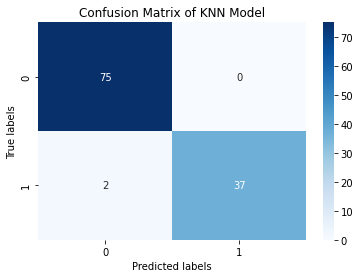

In [34]:
# Data visualization of the confusion matrix
# plt.figure(figsize=(10,10))
photo = sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
photo.set_xlabel('Predicted labels')
photo.set_ylabel('True labels')
photo.set_title('Confusion Matrix of KNN Model')
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
photo.figure.savefig('knn_confusion_matrix.png')

Calculating Accuracy Score  : $\frac{TP + TN}{TP + TN + FP + FN}$ which means True values (Positive & Negative) divided by all values.

```T = True, F = False, P = Positive, N = Negative
TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative 
```

True means correct, and false means incorrect.

get the accuaracy score of the model.

from metrics class that is in the sklearn library import accuracy score function to know the accuaracy of this model.

In [35]:
acc = accuracy_score(y_test,y_pred)
print("Accuracy = " , acc)

Accuracy =  0.9824561403508771


In [36]:
ZeroOneLossValue = zero_one_loss(y_test,y_pred,normalize=False) 
print('Zero One Loss Value: ', ZeroOneLossValue )

Zero One Loss Value:  2


# Applying Naive Bayes Model

Training the Naive Bayes model on the Training set.
from class `naive_bayes` in sklearn library import `GaussianNB` function to train model on training data.

In [37]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

Predicting the Test set results. `classifier.predict` function to predict output.

In [38]:
y_predict = classifier.predict(X_test)

In [39]:
print('Naive Bayes Model Train Score is: ' , classifier.score(X_train, y_train))
print('Naive Bayes Model Test Score is: ' , classifier.score(X_test, y_test))
print('Naive Bayes Model Classes are: ' , classifier.classes_)

Naive Bayes Model Train Score is:  0.9274725274725275
Naive Bayes Model Test Score is:  0.956140350877193
Naive Bayes Model Classes are:  [0 1]


In [40]:
y_pred = classifier.predict(X_test)
y_pred_prob = classifier.predict_proba(X_test)
print('Predicted Value for Naive Bayes Model is: ' , y_pred[:10])
print('Prediction Probabilities Value for Naive Bayes Model is: \n' , y_pred_prob[:10])

Predicted Value for Naive Bayes Model is:  [1 1 0 1 0 0 0 0 1 0]
Prediction Probabilities Value for Naive Bayes Model is: 
 [[4.99019891e-03 9.95009801e-01]
 [3.43851459e-67 1.00000000e+00]
 [1.00000000e+00 2.15514828e-16]
 [1.33269506e-85 1.00000000e+00]
 [9.99999954e-01 4.63873761e-08]
 [1.00000000e+00 5.00786139e-14]
 [1.00000000e+00 5.32181543e-18]
 [9.99891883e-01 1.08117034e-04]
 [5.64105744e-26 1.00000000e+00]
 [1.00000000e+00 1.99116212e-11]]


 Drawing confusion matrix

 ![Confusion Matrix](https://research.aimultiple.com/wp-content/webp-express/webp-images/uploads/2019/07/positive-negative-true-false-matrix.png.webp)

from `metrics` class that is in the sklearn library import `confusion_matrix` function to compare between predected values and actual values to get accuarcy.

In [41]:
cm = confusion_matrix(y_test, y_predict)
print(cm)

[[72  3]
 [ 2 37]]


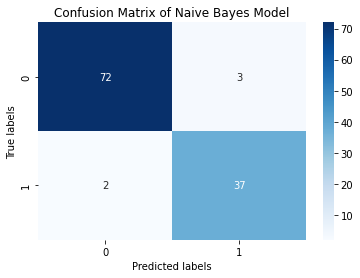

In [42]:
# Data visualization of the confusion matrix
photo = sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
photo.set_xlabel('Predicted labels')
photo.set_ylabel('True labels')
photo.set_title('Confusion Matrix of Naive Bayes Model')
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
photo.figure.savefig('naive_bayes_confusion_matrix.png')

from metrics class that is in the sklearn library import `accuracy_score` function to know the accuaracy of this model .

In [43]:
acc = accuracy_score(y_test,y_predict)
naive_accuracy = acc
print("Accuracy = " , acc)

Accuracy =  0.956140350877193


In [44]:
ZeroOneLossValue = zero_one_loss(y_test,y_pred,normalize=False) 
print('Zero One Loss Value: ', ZeroOneLossValue)

Zero One Loss Value:  5


# Applying Decision Tree Model

In [45]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy',  random_state=44)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=44)

### Model Accuracy & Confusion Matrix

In [46]:
y_pred = classifier.predict(X_test)
y_pred_prob = classifier.predict_proba(X_test)
print('Predicted Value for LogisticRegressionModel is: ' , y_pred[:10])
print('Prediction Probabilities Value for LogisticRegressionModel is: \n' , y_pred_prob[:10])

Predicted Value for LogisticRegressionModel is:  [1 1 0 1 0 0 0 1 1 0]
Prediction Probabilities Value for LogisticRegressionModel is: 
 [[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


In [47]:
# test model it predict correct or no
y_pred = classifier.predict(X_test)
# we will know number of predict it correct and not correct 
cm = confusion_matrix(y_test, y_pred)
print(cm)	# to know the accuracy of model

[[72  3]
 [ 2 37]]


 Drawing confusion matrix

 ![Confusion Matrix](https://research.aimultiple.com/wp-content/webp-express/webp-images/uploads/2019/07/positive-negative-true-false-matrix.png.webp)

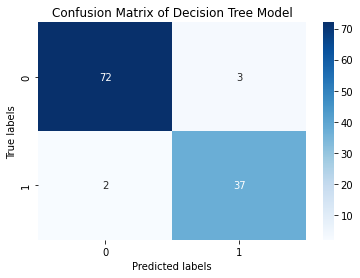

In [48]:
# Data visualization of the confusion matrix
photo = sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
photo.set_xlabel('Predicted labels')
photo.set_ylabel('True labels')
photo.set_title('Confusion Matrix of Decision Tree Model')
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
photo.figure.savefig('decision_tree_confusion_matrix.png')

In [49]:
print('Decision Tree Model Train Score is: ' , classifier.score(X_train, y_train))
print('Decision Tree Model Test Score is: ' , classifier.score(X_test, y_test))
print('Decision Tree Model Classes are: ' , classifier.classes_)

Decision Tree Model Train Score is:  1.0
Decision Tree Model Test Score is:  0.956140350877193
Decision Tree Model Classes are:  [0 1]


In [50]:
acc = accuracy_score(y_test,y_pred)
print("Accuracy = " , acc)

Accuracy =  0.956140350877193


In [51]:
ZeroOneLossValue = zero_one_loss(y_test,y_pred,normalize=False) 
print('Zero One Loss Value: ', ZeroOneLossValue)

Zero One Loss Value:  5


In [52]:
model_dict = {
    "KNN": grid.score(X_test, y_test),
    "LogisticRegression": LogisticRegressionModel.score(X_test, y_test),
    "Naive Bayes": naive_accuracy,
    "DecisionTreeClassifier": classifier.score(X_test, y_test)
}
model_accuracies_df = pd.DataFrame(columns=['Model', 'Accuracy'])
model_accuracies_df['Model'] = model_dict.keys()
model_accuracies_df['Accuracy'] = model_dict.values()
print("Models Accuracies in Descending Order: ")
print(model_accuracies_df.sort_values(by = "Accuracy", ascending=False))

Models Accuracies in Descending Order: 
                    Model  Accuracy
0                     KNN  0.982456
1      LogisticRegression  0.982456
2             Naive Bayes  0.956140
3  DecisionTreeClassifier  0.956140
